<h1 align="center" style="color:#A3B18A;">Deep Learning - Project</h1>
<h3 align="center" style="color:#A3B18A;">Group 13 - Rare Species Classification</h3>

---

### <span style="color:#A3B18A;">Group Members</span>

<table>
  <thead style="color:#A3B18A;">
    <tr>
      <th>Name</th>
      <th>Email</th>
      <th>Student ID</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Afonso Dias</td>
      <td>20211540@novaims.unl.pt</td>
      <td>20211540</td>
    </tr>
    <tr>
      <td>Inês Araújo</td>
      <td>20240532@novaims.unl.pt</td>
      <td>20240532</td>
    </tr>
    <tr>
      <td>Isabel Duarte</td>
      <td>20240545@novaims.unl.pt</td>
      <td>20240545</td>
    </tr>
    <tr>
      <td>Leonor Mira</td>
      <td>20240658@novaims.unl.pt</td>
      <td>20240658</td>
    </tr>
    <tr>
      <td>Rita Matos</td>
      <td>20211642@novaims.unl.pt</td>
      <td>20211642</td>
    </tr>
  </tbody>
</table>


---

<h2 style="color:#A3B18A;">Modelation Notebook - Phylum Hierarchical Classification</h2>

<p><strong style="color:#A3B18A;">Description:</strong></p>

<p>
This notebook focuses on building, training, and evaluating deep learning models for the classification of species.
</p>

<p>Key steps include:</p>

<ul>
  <li><strong style="color:#A3B18A;">Model Definition:</strong> Design and implement convolutional neural network (CNN) architectures tailored for the dataset.</li>
  <li><strong style="color:#A3B18A;">Compilation and Training: </strong> Compile the models with appropriate loss functions, optimizers, and metrics. Train the models using the preprocessed dataset with callbacks for early stopping and learning rate adjustments.</li>
  <li><strong style="color:#A3B18A;">Evaluation:</strong> Assess the model's performance on validation and test datasets using metrics such as accuracy, loss, and F1 score.</li>
  <li><strong style="color:#A3B18A;">Visualization:</strong> Plot training history to analyze the model's learning behavior, including loss and F1 score curves.</li>
</ul>

<p>
This notebook ensures the development of robust models capable of accurately classifying rare species.
</p>

---

<a id="toc"></a>

<h2 style="color:#A3B18A;">Table of Contents</h2>

<ul style="list-style-type:none; padding-left:0;">
  <li><span style="color:#A3B18A;">1.</span> <a href="#chapter1">Import the Libraries</a></li>
  <li><span style="color:#A3B18A;">2.</span> <a href="#chapter2">Load the Data</a></li>
  <li><span style="color:#A3B18A;">3.</span> <a href="#chapter3">Data Augmentation</a> </li>
  <li><span style="color:#A3B18A;">4.</span> <a href="#chapter4">Model Definition</a></li>
  <li><span style="color:#A3B18A;">5.</span> <a href="#chapter5">Compilation and Training</a></li>
  <li><span style="color:#A3B18A;">6.</span> <a href="#chapter6">Evaluation and Visualization</a></li>
</ul>

---

<h2 id="chapter1" style="color:#A3B18A;">1. Import the Libraries</h2>

<p><a href="#toc" style="color:#A3B18A;">⬅ Back to Table of Contents</a></p>

<p>In this section, we import the necessary libraries required throughout this notebook.</p>

In [1]:
# Importing necessary libraries
import pandas as pd
import tensorflow as tf
import os
import random
import numpy as np
import PIL
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from functions import *

from tensorflow.keras import regularizers, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.metrics import Metric
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder

<h2 id="chapter2" style="color:#A3B18A;">2. Load the Data</h2>

<p><a href="#toc" style="color:#A3B18A;">⬅ Back to Table of Contents</a></p>

<p>This section loads the preprocessed data for training, validation, and testing. The data is organized into directories, and labels are extracted for further processing.</p>

In [2]:
# Define directories for training, validation, and testing
split_dir = os.path.join("..", "..", "data", "resized_data_224x224_split")
train_dir = os.path.join(split_dir, 'train')
test_dir = os.path.join(split_dir, 'test')
val_dir = os.path.join(split_dir, 'validation')

# Load training data and fit the encoders
train_paths, train_family_labels, train_phylum_labels, family_encoder, phylum_encoder, unique_phylums = extract_image_data(train_dir)

# Use the same encoders to transform val/test labels
test_paths, test_family_labels, test_phylum_labels, _, _, _ = extract_image_data(test_dir, family_encoder=family_encoder, phylum_encoder=phylum_encoder)
val_paths, val_family_labels, val_phylum_labels, _, _, _ = extract_image_data(val_dir, family_encoder=family_encoder, phylum_encoder=phylum_encoder)

# Print summary
print(f"Loaded {len(train_paths)} training samples.")
print(f"Loaded {len(test_paths)} testing samples.")
print(f"Loaded {len(val_paths)} validation samples.")
print(f"Number of unique phyla: {len(unique_phylums)}")
print(f"Family label shape (train): {train_family_labels.shape}")
print(f"Phylum label shape (train): {train_phylum_labels.shape}")


Loaded 9584 training samples.
Loaded 1200 testing samples.
Loaded 1199 validation samples.
Number of unique phyla: 5
Family label shape (train): (9584, 202)
Phylum label shape (train): (9584, 5)


In [3]:
# Set random seeds 
np.random.seed(42)  
tf.random.set_seed(42) 

<h2 id="chapter3" style="color:#A3B18A;">3. Data Augmentation</h2>

<p><a href="#toc" style="color:#A3B18A;">⬅ Back to Table of Contents</a></p>

<p>Data augmentation is applied to artificially expand the training dataset by applying transformations such as rotations, flips, and zooms. This helps improve the model's generalization ability.</p>

<div style="border-left: 6px solid #A3B18A; padding: 10px; border-radius: 8px;">

<p>In this version of data augmentation, we apply a series of transformations to artificially expand the training dataset. These transformations include:</p>

<ul>
  <li><strong>Rotation:</strong> Randomly rotate images up to 180 degrees.</li>
  <li><strong>Width and Height Shifts:</strong> Shift images horizontally and vertically by up to 25%.</li>
  <li><strong>Shear:</strong> Apply shear transformations to the images.</li>
  <li><strong>Zoom:</strong> Randomly zoom in or out by up to 25%.</li>
  <li><strong>Horizontal Flip:</strong> Flip images horizontally.</li>
  <li><strong>Brightness Range:</strong> Randomly adjust image brightness between 80% and 120% of the original.</li>
  <li><strong>Fill Mode:</strong> Fill missing pixels using the nearest pixel values.</li>
</ul>

<p>These transformations help the model generalize better by exposing it to a variety of variations in the training data.
</p>

In [4]:
# Create the training and validations data generators
train_datagen = data_generator(preprocess_input, augment=True)  
validation_datagen = data_generator(preprocess_input, augment=False)   

# Create the training and validation generators
train_generator = data_flow_gen(train_datagen, train_dir)           
validation_generator = data_flow_gen(validation_datagen, val_dir)    

Found 9584 images belonging to 202 classes.
Found 1199 images belonging to 202 classes.


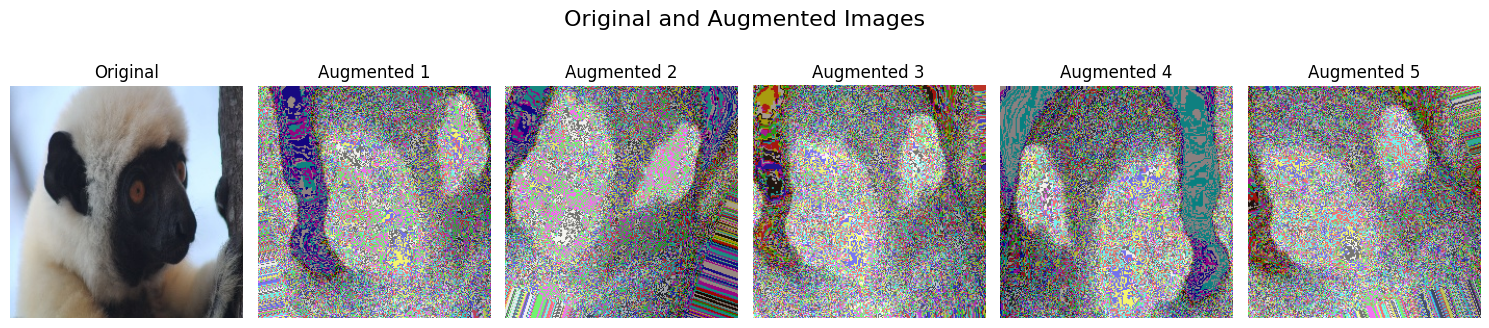

In [5]:
visualize_augmentations(train_paths[5255], train_datagen)

<h2 id="chapter4" style="color:#A3B18A;">4. Model Definition</h2>

<p><a href="#toc" style="color:#A3B18A;">⬅ Back to Table of Contents</a></p>

<p>In this section, we define the architecture of the convolutional neural network (CNN). The model includes convolutional layers for feature extraction, pooling layers for dimensionality reduction, and dense layers for classification.</p>

In [ ]:
# Get the number of unique phyla and families
num_phylums = len(unique_phylums)
num_families = train_family_labels.shape[1]  

# Load EfficientNetB0 base model without the top classifier layer
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Common layers after EfficientNet
gap = layers.GlobalAveragePooling2D()(base_model.output)
dense = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(gap)
bn = layers.BatchNormalization()(dense)
dropout = layers.Dropout(0.5)(bn)

# Output layer for phylum prediction
phylum_output = layers.Dense(num_phylums, activation='softmax', name='phylum_output')(dropout)

# Merge phylum prediction back into family prediction path
merged = layers.Concatenate()([dropout, phylum_output])
family_output = layers.Dense(num_families, activation='softmax', name='family_output')(merged)

# Define the multi-output model
model = models.Model(inputs=base_model.input, outputs=[family_output, phylum_output])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,432,740 (16.91 MB)

 Trainable params: 382,657 (1.46 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

<h2 id="chapter5" style="color:#A3B18A;">5. Compilation and Training</h2>

<p><a href="#toc" style="color:#A3B18A;">⬅ Back to Table of Contents</a></p>

<p>The model is compiled with the Adam optimizer, categorical cross-entropy loss, and evaluation metrics such as accuracy and F1 score. Training is performed using the augmented dataset, with callbacks for early stopping and learning rate adjustments.</p>

In [ ]:
train_generator_family = data_flow_gen(train_datagen, train_dir, shuffle = True)
validation_generator_family = data_flow_gen(validation_datagen, val_dir, shuffle = False)

# Create the multi-output generators
train_multi_output_generator = multi_task_gen(train_generator_family, train_phylum_labels)
validation_multi_output_generator = multi_task_gen(validation_generator_family, val_phylum_labels)

# Get the number of steps per epoch
train_steps = len(train_generator_family)
val_steps = len(validation_generator_family)


# Create callbacks for the multi-task model
model_callbacks_mtl = build_callbacks()

# Compile model using the created function
model_mtl = compile_model(model) 

# Fit the multi-output model
history_mtl = model_mtl.fit(
    train_multi_output_generator,
    steps_per_epoch=train_steps,
    validation_data=validation_multi_output_generator,
    validation_steps=val_steps,
    epochs=50,
    callbacks=model_callbacks_mtl,
    verbose=1 
)

Found 9584 images belonging to 202 classes.
Found 1199 images belonging to 202 classes.
Epoch 1/50
599/599 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - family_output_accuracy: 0.1751 - family_output_family_f1_score: 0.0906 - family_output_family_loss: 4.4368 - family_output_loss: 4.4368 - loss: 8.7180 - phylum_output_accuracy: 0.5152 - phylum_output_loss: 1.5015 - phylum_output_phylum_loss: 1.5015
Epoch 1: val_family_output_family_f1_score improved from -inf to 0.37392, saving model to ./Callbacks_mtl\history_mtl_callbacks\best_model_family_f1.weights.h5
599/599 ━━━━━━━━━━━━━━━━━━━━ 449s 696ms/step - family_output_accuracy: 0.1753 - family_output_family_f1_score: 0.0908 - family_output_family_loss: 4.4354 - family_output_loss: 4.4354 - loss: 8.7152 - phylum_output_accuracy: 0.5155 - phylum_output_loss: 1.5009 - phylum_output_phylum_loss: 1.5009 - val_family_output_accuracy: 0.4862 - val_family_output_family_f1_score: 0.3739 - val_family_output_family_loss: 2.1619 - val_family_output_loss: 2.16

<h2 id="chapter6" style="color:#A3B18A;">6. Evaluation and Visualization</h2>

<p><a href="#toc" style="color:#A3B18A;">⬅ Back to Table of Contents</a></p>

<p>After training, the model's performance is evaluated on the validation and test datasets. Metrics such as accuracy, loss, and F1 score are analyzed. Training history is visualized to understand the model's learning behavior.</p>

<div style="border-left: 6px solid #A3B18A; padding: 10px; border-radius: 8px;">

<h2 id="chapter6-1" style="color:#A3B18A;">Results Visualization</h2>

<p> Visualizing results is essential for evaluating and understanding the performance of deep learning models. By analyzing key metrics across training, validation, and test datasets, we can gain deeper insights into the model’s learning behavior.

Plots such as loss, accuracy, and F1-score curves reveal important trends, convergence patterns, and potential issues like overfitting or underfitting. Additionally, visual tools like the confusion matrix highlight misclassifications, making it easier to identify problematic classes and guide further model refinement for improved performance.</p>

</div>

Final Family Classification Metrics:
Train Accuracy: 0.7270, F1 Score: 0.7261, Loss: 0.9624
Validation Accuracy: 0.6956, F1 Score: 0.6431, Loss: 1.2055

Final Phylum Classification Metrics:
Train Accuracy: 0.8306, Loss: 0.6555
Validation Accuracy: 0.8040, Loss: 0.7177


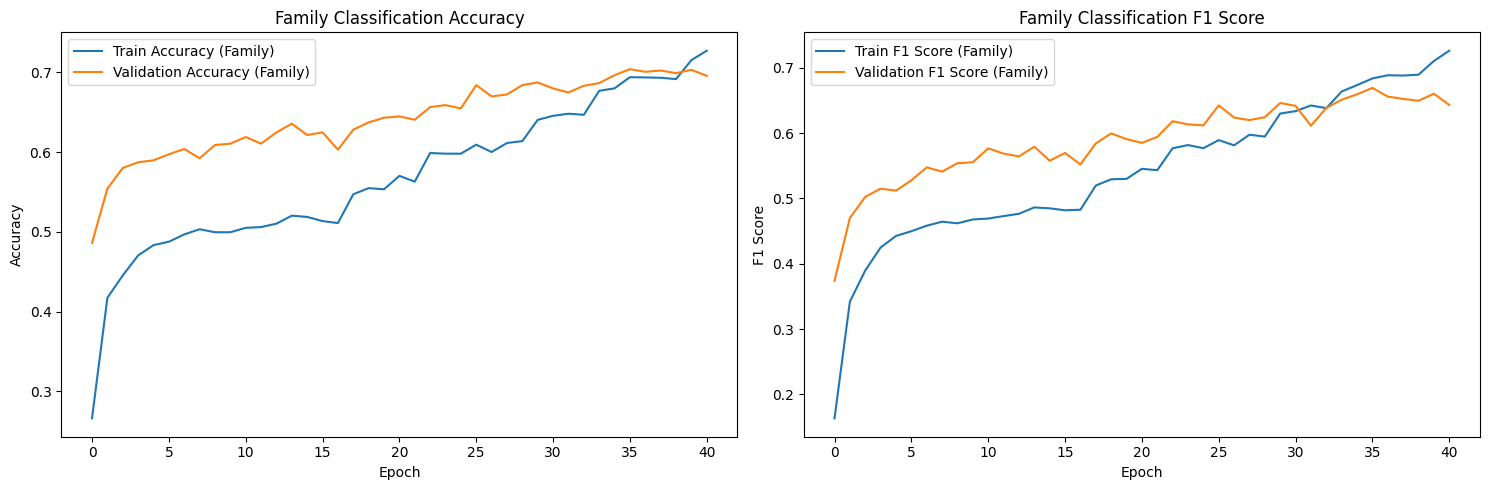

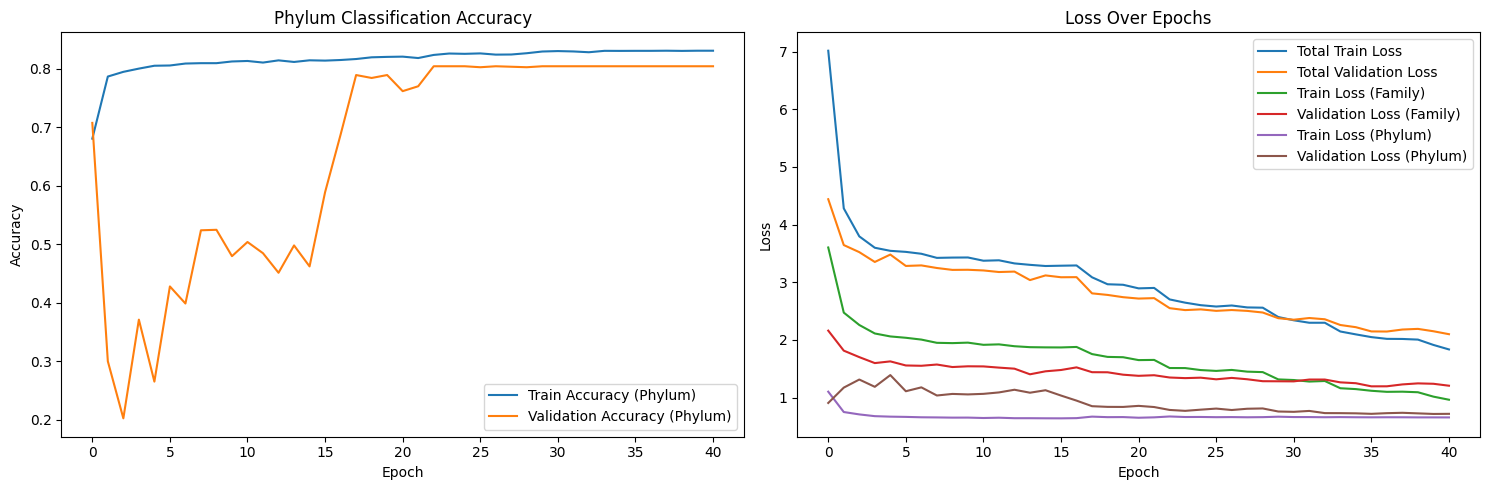

In [ ]:
# Assuming history_mtl is the history object from the multi-task learning training
acc_family, f1_family, loss_family = history_mtl.history['family_output_accuracy'][-1], history_mtl.history['family_output_family_f1_score'][-1], history_mtl.history['family_output_loss'][-1]
val_acc_family, val_f1_family, val_loss_family = history_mtl.history['val_family_output_accuracy'][-1], history_mtl.history['val_family_output_family_f1_score'][-1], history_mtl.history['val_family_output_loss'][-1]

acc_phylum, loss_phylum = history_mtl.history['phylum_output_accuracy'][-1], history_mtl.history['phylum_output_loss'][-1]
val_acc_phylum, val_loss_phylum = history_mtl.history['val_phylum_output_accuracy'][-1], history_mtl.history['val_phylum_output_loss'][-1]

print("Final Family Classification Metrics:")
print(f"Train Accuracy: {acc_family:.4f}, F1 Score: {f1_family:.4f}, Loss: {loss_family:.4f}")
print(f"Validation Accuracy: {val_acc_family:.4f}, F1 Score: {val_f1_family:.4f}, Loss: {val_loss_family:.4f}")

print("\nFinal Phylum Classification Metrics:")
print(f"Train Accuracy: {acc_phylum:.4f}, Loss: {loss_phylum:.4f}")
print(f"Validation Accuracy: {val_acc_phylum:.4f}, Loss: {val_loss_phylum:.4f}")

# Plotting the results
visualize_training_progress(history_mtl)

In [ ]:
# Get true labels from the generator (for family classification)
y_true_family = validation_generator_family.classes

# Get class names from the generator (for family classification)
class_names_family = list(validation_generator_family.class_indices.keys())

# Get predictions from the multi-task model (IMPORTANT: specify steps to prevent infinite loop)
predictions = model_mtl.predict(validation_multi_output_generator, steps=val_steps, verbose=1)

# Process family predictions
y_pred_probs_family = predictions[0]  
y_pred_family = np.argmax(y_pred_probs_family, axis=1)

# Process phylum predictions
y_pred_probs_phylum = predictions[1]  
y_pred_phylum = np.argmax(y_pred_probs_phylum, axis=1)

# Optional: Get true phylum labels (assuming you have them as one-hot encoded)
y_true_phylum = np.argmax(val_phylum_labels, axis=1)

75/75 ━━━━━━━━━━━━━━━━━━━━ 39s 472ms/step


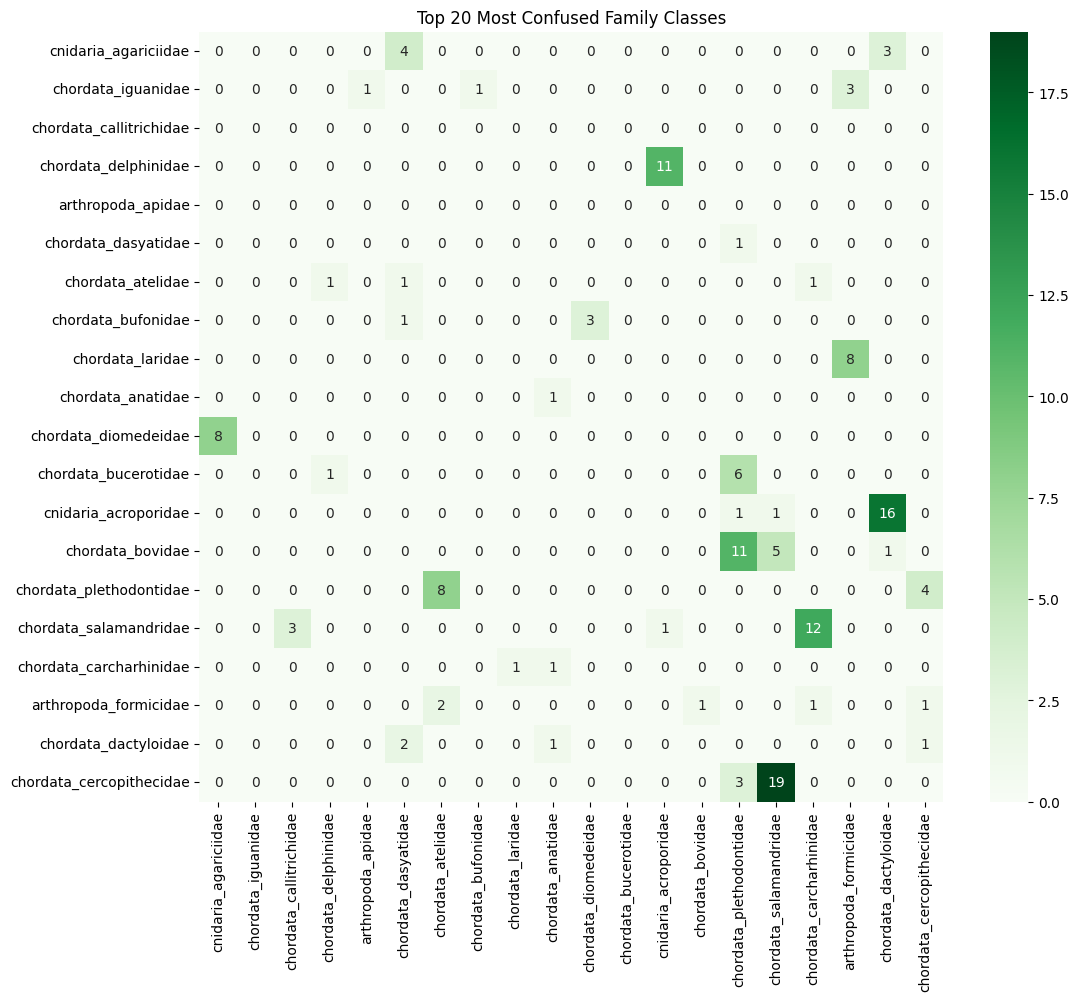

In [ ]:
# cm: your full confusion matrix for family classification
cm_family = confusion_matrix(y_true_family, y_pred_family)
# sum of incorrect predictions per class (excluding the diagonal)
errors_per_class_family = cm_family.sum(axis=1) - np.diag(cm_family)

# get indices of top 20 most confused classes (family)
top_n = 20
most_confused_family = np.argsort(errors_per_class_family)[-top_n:]

# subset the confusion matrix
cm_subset_family = cm_family[np.ix_(most_confused_family, most_confused_family)]

# optional: get class names if you have them
subset_labels_family = [class_names_family[i] for i in most_confused_family]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_subset_family, annot=True, fmt='d', xticklabels=subset_labels_family, yticklabels=subset_labels_family, cmap='Greens')
plt.title("Top 20 Most Confused Family Classes")
plt.show()